<a href="https://colab.research.google.com/github/siojzz/Practical-Statistics-for-Data-Scientists/blob/main/PracticalStatisticsChapter4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 4 - Regression and Prediction

This notebook contains my code reproduction and notes for Chapter 4 of *Practical Statistics for Data Scientists*.

This chapter focuses on regression models and how they can be used to understand relationships between variables and make predictions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import statsmodels.api as sm
import statsmodels.formula.api as smf

## 1. Simple Linear Regression

Simple linear regression models the relationship between one predictor variable and one response variable.

The regression equation is:

Y = b0 + b1X

where b0 is the intercept and b1 is the regression coefficient or slope.

In [2]:
base = "https://" + "raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data"

!wget -O LungDisease.csv "{base}/LungDisease.csv"

--2026-10-01 07:22:10--  https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/LungDisease.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 832 [text/plain]
Saving to: ‘LungDisease.csv’

LungDisease.csv     100%[===================>]     832  --.-KB/s    in 0s      

2026-10-01 07:22:10 (49.8 MB/s) - ‘LungDisease.csv’ saved [832/832]



In [3]:
lung = pd.read_csv("LungDisease.csv")

lung.head()

,PEFR,Exposure
0,390,0
1,410,0
2,430,0
3,460,0
4,420,1


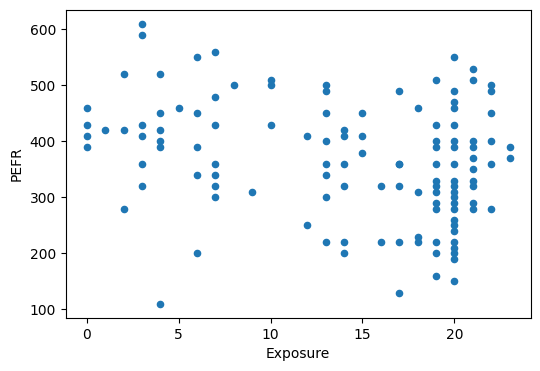

In [4]:
lung.plot.scatter(
    x="Exposure",
    y="PEFR",
    figsize=(6, 4)
)

plt.show()

### 1.1 Regression Equation

The regression model finds a line that describes the relationship between the predictor and response variables.

The intercept represents the predicted response when the predictor is zero.

The coefficient represents how much the response changes when the predictor increases by one unit.

In [5]:
predictors = ["Exposure"]
outcome = "PEFR"

model = LinearRegression()

model.fit(
    lung[predictors],
    lung[outcome]
)

print(f"Intercept: {model.intercept_:.3f}")
print(f"Coefficient Exposure: {model.coef_[0]:.3f}")

Intercept: 424.583
Coefficient Exposure: -4.185


**Interpretation:**

The coefficient is negative.

This means that as exposure increases, the predicted PEFR tends to decrease.

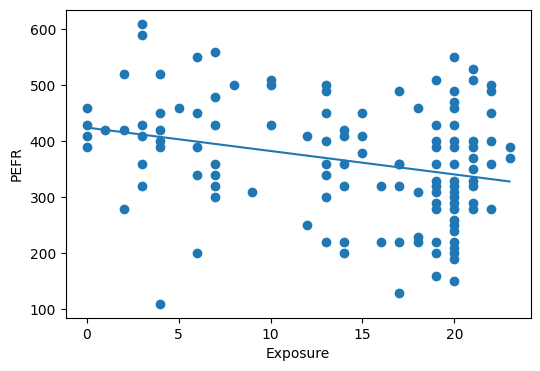

In [6]:
plt.figure(figsize=(6, 4))

plt.scatter(
    lung["Exposure"],
    lung["PEFR"]
)

plt.plot(
    lung["Exposure"],
    model.predict(lung[predictors])
)

plt.xlabel("Exposure")
plt.ylabel("PEFR")

plt.show()

## 2. Fitted Values and Residuals

Fitted values are the values predicted by the regression model.

Residuals are the differences between the actual values and the predicted values.

Residual = Actual Value - Predicted Value

In [7]:
fitted = model.predict(lung[predictors])

residuals = (
    lung[outcome] - fitted
)

print("First fitted values:")
print(fitted[:5])

print("\nFirst residuals:")
print(residuals.head())

First fitted values:
[424.58280657 424.58280657 424.58280657 424.58280657 420.39823009]

First residuals:
0   -34.582807
1   -14.582807
2     5.417193
3    35.417193
4    -0.398230
Name: PEFR, dtype: float64


**Interpretation:**

A residual shows the prediction error for each observation.

A small residual means the predicted value is close to the actual value, while a large residual means the prediction is farther from the actual value.

## 3. Least Squares

Least squares is the common method used to fit a linear regression model.

It finds the regression line that minimizes the sum of squared residuals.

This quantity is also called the Residual Sum of Squares (RSS).

## 4. Prediction Versus Explanation

Regression can be used for two different goals.

For explanation, the goal is to understand the relationship between predictor variables and the response.

For prediction, the goal is to use the fitted model to predict the response for new observations.

A regression relationship by itself does not prove causation.

## 5. Multiple Linear Regression

Multiple linear regression extends simple linear regression by using several predictor variables.

The general form is:

Y = b0 + b1X1 + b2X2 + ... + bpXp

Each coefficient represents the relationship between one predictor and the response while the other predictors are held constant.

In [8]:
!wget -O house_sales.csv "{base}/house_sales.csv"

--2026-10-01 07:25:40--  https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/house_sales.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3545162 (3.4M) [text/plain]
Saving to: ‘house_sales.csv’

house_sales.csv     100%[===================>]   3.38M  --.-KB/s    in 0.02s   

2026-10-01 07:25:40 (148 MB/s) - ‘house_sales.csv’ saved [3545162/3545162]



In [9]:
house = pd.read_csv("house_sales.csv", sep="\t")

house.head()

,DocumentDate,SalePrice,PropertyID,PropertyType,ym,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,...,Bathrooms,Bedrooms,BldgGrade,YrBuilt,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode,NewConstruction
1,2014-09-16,280000,1000102,Multiplex,2014-09-01,405100,0.930836,300805.0,2,9373,...,3.00,6,7,1991,0,0,70000,229000,98002,False
2,2006-06-16,1000000,1200013,Single Family,2006-06-01,404400,0.929228,1076162.0,1,20156,...,3.75,4,10,2005,0,0,203000,590000,98166,True
3,2007-01-29,745000,1200019,Single Family,2007-01-01,425600,0.977941,761805.0,1,26036,...,1.75,4,8,1947,0,0,183000,275000,98166,False
4,2008-02-25,425000,2800016,Single Family,2008-02-01,418400,0.961397,442065.0,1,8618,...,3.75,5,7,1966,0,0,104000,229000,98168,False
5,2013-03-29,240000,2800024,Single Family,2013-03-01,351600,0.807904,297065.0,1,8620,...,1.75,4,7,1948,0,0,104000,205000,98168,False


In [10]:
subset = [
    "AdjSalePrice",
    "SqFtTotLiving",
    "SqFtLot",
    "Bathrooms",
    "Bedrooms",
    "BldgGrade"
]

house[subset].head()

,AdjSalePrice,SqFtTotLiving,SqFtLot,Bathrooms,Bedrooms,BldgGrade
1,300805.0,2400,9373,3.00,6,7
2,1076162.0,3764,20156,3.75,4,10
3,761805.0,2060,26036,1.75,4,8
4,442065.0,3200,8618,3.75,5,7
5,297065.0,1720,8620,1.75,4,7


In [11]:
predictors = [
    "SqFtTotLiving",
    "SqFtLot",
    "Bathrooms",
    "Bedrooms",
    "BldgGrade"
]

outcome = "AdjSalePrice"

house_lm = LinearRegression()

house_lm.fit(
    house[predictors],
    house[outcome]
)

LinearRegression()

In [12]:
print(f"Intercept: {house_lm.intercept_:.3f}")

print("Coefficients:")

for name, coef in zip(
    predictors,
    house_lm.coef_
):
    print(f"{name}: {coef}")

Intercept: -521871.368
Coefficients:
SqFtTotLiving: 228.83060360240793
SqFtLot: -0.06046682065307607
Bathrooms: -19442.840398321066
Bedrooms: -47769.95518521438
BldgGrade: 106106.96307898081


**Interpretation:**

Each coefficient represents how the predicted house price changes when one predictor changes while the other predictors are kept constant.

The model uses several house characteristics together to estimate the sale price.

## 6. Assessing the Model

Regression models can be evaluated using metrics such as RMSE and R-squared.

RMSE measures the size of the prediction errors.

R-squared measures the proportion of variation in the response that is explained by the regression model.

In [13]:
fitted = house_lm.predict(
    house[predictors]
)

RMSE = np.sqrt(
    mean_squared_error(
        house[outcome],
        fitted
    )
)

r2 = r2_score(
    house[outcome],
    fitted
)

print(f"RMSE: {RMSE:.0f}")
print(f"R-squared: {r2:.4f}")

RMSE: 261220
R-squared: 0.5406


**Interpretation:**

The R-squared value is around 0.54.

This means that the predictors in the model explain around 54% of the variation in adjusted house sale prices.

RMSE represents the typical size of the model's prediction errors.

## 7. Cross-Validation

Cross-validation is used to evaluate how well a model performs on data that was not used to train it.

In k-fold cross-validation, the data is divided into several parts called folds.

The model is trained using most of the folds and evaluated using the remaining fold. This process is repeated until every fold has been used for evaluation.

## 8. Model Selection

A regression model can contain many possible predictor variables.

However, adding more predictors does not always create a better model.

Model selection is used to find a simpler model that still provides useful predictive performance.

In [14]:
full_predictors = [
    "SqFtTotLiving",
    "SqFtLot",
    "Bathrooms",
    "Bedrooms",
    "BldgGrade",
    "PropertyType",
    "NbrLivingUnits",
    "SqFtFinBasement",
    "YrBuilt",
    "YrRenovated",
    "NewConstruction"
]

X = pd.get_dummies(
    house[full_predictors],
    drop_first=True
)

X["NewConstruction"] = [
    1 if nc else 0
    for nc in X["NewConstruction"]
]

house_full = sm.OLS(
    house[outcome],
    X.assign(const=1)
)

results = house_full.fit()

results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           AdjSalePrice   R-squared:                       0.595
Model:                            OLS   Adj. R-squared:                  0.594
Method:                 Least Squares   F-statistic:                     2771.
Date:                Thu, 01 Oct 2026   Prob (F-statistic):               0.00
Time:                        07:32:12   Log-Likelihood:            -3.1375e+05
No. Observations:               22687   AIC:                         6.275e+05
Df Residuals:                   22674   BIC:                         6.276e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
SqFtTotLiving                198.6364      4.234     46.920      0.000     190.338     206.934
SqFtLot                        0.0771      0.058      1.330      0.184      -0.037       0.191
Bathrooms                   4.286e+04   3808.114     11.255      0.000    3.54e+04    5.03e+04
Bedrooms                   -5.187e+04   2396.904    -21.638      0.000   -5.66e+04   -4.72e+04
BldgGrade                   1.373e+05   2441.242     56.228      0.000    1.32e+05    1.42e+05
NbrLivingUnits              5723.8438   1.76e+04      0.326      0.744   -2.87e+04    4.01e+04
SqFtFinBasement                7.0611      4.627      1.526      0.127      -2.009      16.131
YrBuilt                    -3574.2210     77.228    -46.282      0.000   -3725.593   -3422.849
YrRenovated                   -2.5311      3.924     -0.645      0.519     -10.222       5.160
NewConstruction            -2489.1122   5936.692     -0.419      0.675   -1.41e+04    9147.211
PropertyType_Single Family  2.997e+04   2.61e+04      1.149      0.251   -2.12e+04    8.11e+04
PropertyType_Townhouse      9.286e+04    2.7e+04      3.438      0.001    3.99e+04    1.46e+05
const                       6.182e+06   1.55e+05     39.902      0.000    5.88e+06    6.49e+06
==============================================================================
Omnibus:                    31006.128   Durbin-Watson:                   1.393
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         26251977.078
Skew:                           7.427   Prob(JB):                         0.00
Kurtosis:                     168.984   Cond. No.                     2.98e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.98e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

**Interpretation:**

The full regression model uses more predictor variables than the previous model.

However, a more complex model is not always better because additional predictors can increase model complexity and may lead to overfitting.

## 9. Weighted Regression

Weighted regression gives different levels of importance to different observations.

Observations with larger weights have a greater influence on the fitted regression model.

In the housing example, newer house sales are given more weight than older sales.

In [15]:
house["Year"] = [
    int(date.split("-")[0])
    for date in house["DocumentDate"]
]

house["Weight"] = house["Year"] - 2005

house[["DocumentDate", "Year", "Weight"]].head()

,DocumentDate,Year,Weight
1,2014-09-16,2014,9
2,2006-06-16,2006,1
3,2007-01-29,2007,2
4,2008-02-25,2008,3
5,2013-03-29,2013,8


In [16]:
predictors = [
    "SqFtTotLiving",
    "SqFtLot",
    "Bathrooms",
    "Bedrooms",
    "BldgGrade"
]

outcome = "AdjSalePrice"

house_wt = LinearRegression()

house_wt.fit(
    house[predictors],
    house[outcome],
    sample_weight=house["Weight"]
)

LinearRegression()

In [17]:
print(f"Intercept: {house_wt.intercept_:.3f}")

print("Coefficients:")

for name, coef in zip(
    predictors,
    house_wt.coef_
):
    print(f"{name}: {coef}")

Intercept: -584189.329
Coefficients:
SqFtTotLiving: 245.02408862720128
SqFtLot: -0.292414748005541
Bathrooms: -26085.97010861501
Bedrooms: -53608.876436313745
BldgGrade: 115242.43472609237


**Interpretation:**

The coefficients from the weighted regression are slightly different from the original regression model.

This happens because more recent observations have greater influence on the model.

## 10. Prediction Using Regression

One of the main purposes of regression in data science is to predict outcomes for new observations.

A regression model should generally make predictions within the range of data that was used to train the model.

Using the model far outside the observed data range is called extrapolation and may produce unrealistic predictions.

In [18]:
new_house = pd.DataFrame({
    "SqFtTotLiving": [2000],
    "SqFtLot": [8000],
    "Bathrooms": [2.5],
    "Bedrooms": [3],
    "BldgGrade": [8]
})

predicted_price = house_lm.predict(new_house)

print(
    f"Predicted Price: ${predicted_price[0]:,.2f}"
)

Predicted Price: $592,244.84


**Interpretation:**

The regression model uses the characteristics of the new house to estimate its adjusted sale price.

The prediction should be interpreted carefully because regression predictions also contain uncertainty.

### Confidence and Prediction Intervals

A confidence interval describes uncertainty around an estimated regression value or coefficient.

A prediction interval describes uncertainty around an individual predicted observation.

Prediction intervals are usually wider because individual predictions contain additional variability.

## 11. Factor Variables in Regression

Regression models require numerical input.

Categorical variables therefore need to be converted into numerical variables before they can be used in a regression model.

A common method is to use dummy variables.

In [19]:
house["PropertyType"].head()

,PropertyType
1,Multiplex
2,Single Family
3,Single Family
4,Single Family
5,Single Family


In [20]:
pd.get_dummies(
    house["PropertyType"]
).head()

,Multiplex,Single Family,Townhouse
1,True,False,False
2,False,True,False
3,False,True,False
4,False,True,False
5,False,True,False


In [21]:
pd.get_dummies(
    house["PropertyType"],
    drop_first=True
).head()

,Single Family,Townhouse
1,False,False
2,True,False
3,True,False
4,True,False
5,True,False


**Interpretation:**

Dummy variables convert categorical values into numerical columns containing True/False or 0/1 values.

Using `drop_first=True` removes one category that becomes the reference category and helps avoid redundant predictors.

## 12. Correlated Predictors and Multicollinearity

Predictor variables in a regression model can be correlated with each other.

When predictors contain very similar information, it can become difficult to interpret their coefficients.

Multicollinearity is an extreme case where predictor variables are highly redundant. This can make regression coefficients unstable.

### Confounding Variables

A confounding variable is an important predictor that is missing from the regression model.

If an important variable is not included, the coefficients of the other variables may give misleading interpretations.

For example, location is an important factor when predicting house prices.

### Confounding Variables

A confounding variable is an important predictor that is missing from the regression model.

If an important variable is not included, the coefficients of the other variables may give misleading interpretations.

For example, location is an important factor when predicting house prices.

## 13. Interactions and Main Effects

An interaction occurs when the effect of one predictor depends on the value of another predictor.

This means that the effect of a variable is not always the same for every observation.

For example, the effect of house size on price may be different depending on the location of the house.

In [22]:
import seaborn as sns

from statsmodels.stats.outliers_influence import OLSInfluence

## 14. Regression Diagnostics

Regression diagnostics are used to examine problems in a regression model.

Some important diagnostic concepts are:

- Residuals
- Outliers
- Influential observations
- Leverage
- Heteroskedasticity

Residual analysis can help identify observations or patterns that are not explained well by the regression model.

In [23]:
house_98105 = house.loc[
    house["ZipCode"] == 98105
].copy()

predictors = [
    "SqFtTotLiving",
    "SqFtLot",
    "Bathrooms",
    "Bedrooms",
    "BldgGrade"
]

outcome = "AdjSalePrice"

house_outlier = sm.OLS(
    house_98105[outcome],
    house_98105[predictors].assign(const=1)
)

result_98105 = house_outlier.fit()

result_98105.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           AdjSalePrice   R-squared:                       0.795
Model:                            OLS   Adj. R-squared:                  0.792
Method:                 Least Squares   F-statistic:                     238.7
Date:                Thu, 01 Oct 2026   Prob (F-statistic):          1.69e-103
Time:                        07:35:06   Log-Likelihood:                -4226.0
No. Observations:                 313   AIC:                             8464.
Df Residuals:                     307   BIC:                             8486.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
SqFtTotLiving   209.6023     24.408      8.587      0.000     161.574     257.631
SqFtLot          38.9333      5.330      7.305      0.000      28.445      49.421
Bathrooms      2282.2641      2e+04      0.114      0.909    -3.7e+04    4.16e+04
Bedrooms      -2.632e+04   1.29e+04     -2.043      0.042   -5.17e+04    -973.867
BldgGrade        1.3e+05   1.52e+04      8.533      0.000       1e+05     1.6e+05
const         -7.725e+05   9.83e+04     -7.861      0.000   -9.66e+05   -5.79e+05
==============================================================================
Omnibus:                       82.127   Durbin-Watson:                   1.508
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              586.561
Skew:                           0.859   Prob(JB):                    4.26e-128
Kurtosis:                       9.483   Cond. No.                     5.63e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.63e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### 14.1 Outliers

In regression, an outlier is an observation where the actual response is far from the predicted response.

Standardized residuals can be used to identify observations that are unusually far from the regression model.

In [24]:
influence = OLSInfluence(result_98105)

sresiduals = influence.resid_studentized_internal

print(
    "Lowest standardized residual:",
    sresiduals.min()
)

print(
    "Observation index:",
    sresiduals.argmin()
)

Lowest standardized residual: -4.32673180407856
Observation index: 258


**Interpretation:**

A very large positive or negative standardized residual may indicate an unusual observation.

These observations should be investigated because they may represent data errors, unusual cases, or important anomalies.

### 14.2 Heteroskedasticity

Heteroskedasticity happens when the variability of the residuals changes across different predicted values.

Ideally, the spread of residuals should be relatively consistent.

A changing residual spread may indicate that the regression model does not fully explain the data.

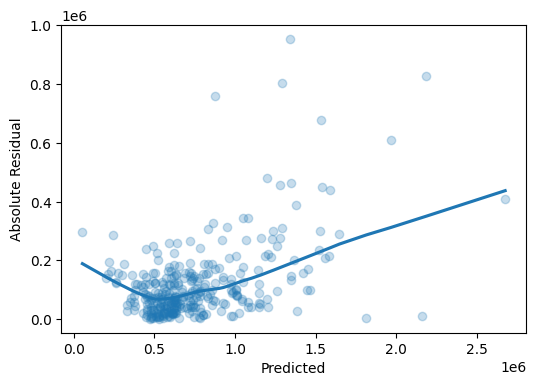

In [25]:
fig, ax = plt.subplots(figsize=(6, 4))

sns.regplot(
    x=result_98105.fittedvalues,
    y=np.abs(result_98105.resid),
    scatter_kws={"alpha": 0.25},
    lowess=True,
    ax=ax
)

ax.set_xlabel("Predicted")
ax.set_ylabel("Absolute Residual")

plt.show()

**Interpretation:**

The residual plot helps show whether prediction errors have a similar spread across different predicted values.

If the spread changes strongly, the model may have heteroskedastic errors.

## 15. Polynomial Regression

Linear regression assumes a linear relationship between predictors and the response.

Polynomial regression can model curved relationships by adding polynomial terms such as X².

A quadratic regression includes both the original predictor and its squared value.

In [26]:
model_poly = smf.ols(
    formula=(
        "AdjSalePrice ~ SqFtTotLiving "
        "+ I(SqFtTotLiving**2) "
        "+ SqFtLot + Bathrooms + Bedrooms + BldgGrade"
    ),
    data=house_98105
)

result_poly = model_poly.fit()

result_poly.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           AdjSalePrice   R-squared:                       0.806
Model:                            OLS   Adj. R-squared:                  0.802
Method:                 Least Squares   F-statistic:                     211.6
Date:                Thu, 01 Oct 2026   Prob (F-statistic):          9.95e-106
Time:                        07:35:55   Log-Likelihood:                -4217.9
No. Observations:                 313   AIC:                             8450.
Df Residuals:                     306   BIC:                             8476.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept             -6.159e+05   1.03e+05     -5.953      0.000   -8.19e+05   -4.12e+05
SqFtTotLiving             7.4521     55.418      0.134      0.893    -101.597     116.501
I(SqFtTotLiving ** 2)     0.0388      0.010      4.040      0.000       0.020       0.058
SqFtLot                  32.5594      5.436      5.990      0.000      21.863      43.256
Bathrooms             -1435.1231   1.95e+04     -0.074      0.941   -3.99e+04     3.7e+04
Bedrooms              -9191.9441   1.33e+04     -0.693      0.489   -3.53e+04    1.69e+04
BldgGrade              1.357e+05   1.49e+04      9.087      0.000    1.06e+05    1.65e+05
==============================================================================
Omnibus:                       75.161   Durbin-Watson:                   1.625
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              637.978
Skew:                           0.699   Prob(JB):                    2.92e-139
Kurtosis:                       9.853   Cond. No.                     7.37e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.37e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

**Interpretation:**

The polynomial model includes both a linear and quadratic term for house size.

This allows the model to represent a curved relationship between house size and sale price instead of forcing the relationship to be completely linear.

## 16. Splines

Splines provide another way to model nonlinear relationships.

Instead of using one polynomial for the entire range of data, splines combine several polynomial sections.

The points where these sections connect are called knots.

In [27]:
formula = (
    "AdjSalePrice ~ bs(SqFtTotLiving, df=6, degree=3) "
    "+ SqFtLot + Bathrooms + Bedrooms + BldgGrade"
)

model_spline = smf.ols(
    formula=formula,
    data=house_98105
)

result_spline = model_spline.fit()

result_spline.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           AdjSalePrice   R-squared:                       0.814
Model:                            OLS   Adj. R-squared:                  0.807
Method:                 Least Squares   F-statistic:                     131.8
Date:                Thu, 01 Oct 2026   Prob (F-statistic):          7.10e-104
Time:                        07:36:28   Log-Likelihood:                -4211.4
No. Observations:                 313   AIC:                             8445.
Df Residuals:                     302   BIC:                             8486.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
========================================================================================================
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
Intercept                            -4.142e+05   1.43e+05     -2.899      0.004   -6.95e+05   -1.33e+05
bs(SqFtTotLiving, df=6, degree=3)[0] -1.995e+05   1.86e+05     -1.076      0.283   -5.65e+05    1.66e+05
bs(SqFtTotLiving, df=6, degree=3)[1] -1.206e+05   1.23e+05     -0.983      0.326   -3.62e+05    1.21e+05
bs(SqFtTotLiving, df=6, degree=3)[2] -7.164e+04   1.36e+05     -0.525      0.600    -3.4e+05    1.97e+05
bs(SqFtTotLiving, df=6, degree=3)[3]  1.957e+05   1.62e+05      1.212      0.227   -1.22e+05    5.14e+05
bs(SqFtTotLiving, df=6, degree=3)[4]  8.452e+05   2.18e+05      3.878      0.000    4.16e+05    1.27e+06
bs(SqFtTotLiving, df=6, degree=3)[5]  6.955e+05   2.14e+05      3.255      0.001    2.75e+05    1.12e+06
SqFtLot                                 33.3258      5.454      6.110      0.000      22.592      44.059
Bathrooms                            -4778.2080   1.94e+04     -0.246      0.806    -4.3e+04    3.34e+04
Bedrooms                             -5778.7045   1.32e+04     -0.437      0.663   -3.18e+04    2.03e+04
BldgGrade                             1.345e+05   1.52e+04      8.842      0.000    1.05e+05    1.64e+05
==============================================================================
Omnibus:                       58.816   Durbin-Watson:                   1.633
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              622.021
Skew:                           0.330   Prob(JB):                    8.51e-136
Kurtosis:                       9.874   Cond. No.                     1.97e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.97e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
**Interpretation:**

The spline model provides more flexibility than a simple linear regression.

It can capture changes in the relationship between house size and sale price across different ranges of house size.

## 17. Generalized Additive Models

A Generalized Additive Model (GAM) is a flexible model that can automatically model nonlinear relationships.

GAM can use smooth functions for some predictors while keeping other predictors linear.

It provides more flexibility than ordinary linear regression while still keeping the model relatively interpretable.

## 18. Chapter Summary

In this chapter, I learned how regression can be used to understand relationships between variables and make predictions.

The main topics covered were:

- Simple linear regression
- Regression equations
- Fitted values and residuals
- Least squares
- Multiple linear regression
- RMSE and R-squared
- Cross-validation
- Model selection
- Weighted regression
- Regression prediction
- Factor and dummy variables
- Correlated predictors and multicollinearity
- Confounding variables
- Interaction effects
- Regression diagnostics
- Outliers and heteroskedasticity
- Polynomial regression
- Splines
- Generalized Additive Models

Linear regression is useful for modeling relationships between predictors and a numerical outcome. More flexible methods such as polynomial regression, splines, and GAM can be used when the relationship is not completely linear.